<div style="text-align: center;">

# Multi-Hazard Climate Screening: Seville Parkings

</div>

This notebook shows how to run a client-facing multi-hazard screening workflow for a small parking portfolio. It combines hazard scores, selected loss views, and aggregated portfolio outputs in one end-to-end narrative. The notebook builds on the API fundamentals notebooks and applies the same ideas to a portfolio context.

The workflow is:

1. load configuration, credentials, and helper modules,
2. inspect the portfolio,
3. review hazard scores across multiple hazards,
4. zoom in on selected material hazards at asset level,
5. use clustering to identify correlated acute-hazard exposure,
6. aggregate results into a portfolio view,
7. preserve provenance and methodological traceability.

**New to the Alpha-Klima API?** You may want to explore `01_hazard_data_api_basics.ipynb` and `02_asset_impact_api_basics.ipynb` first. Those notebooks introduce the raw hazard-data and asset-impact responses used here. This notebook assumes those API ideas are familiar enough that we can focus on portfolio interpretation.

## 1. Setup

When you run the notebook for the first time, select `.venv` as the interpreter. If you are unable to find the `.venv` interpreter, please follow the *Setup* instructions in the `README.md` to set it up.

### 1.1 Imports

The notebook uses a mix of standard Python packages and project-specific helpers:

* `json` loads the parking portfolio input data.
* `os`, `sys`, `pathlib`, and `python-dotenv` handle configuration, paths, and API credentials.
* `time` supports retry delays for API requests.
* `numpy` and `pandas` handle numerical operations and tabular results.
* `plotly` creates the screening and financial visualizations.
* `requests` sends HTTPS requests to the Alpha-Klima API.
* `cooling_model`, `financial_metrics_plots`, `geometry_maps_plots`, and `tail_metrics` provide reusable project-specific calculations and plots.
* `IPython.display` displays tables directly in the notebook.

In [1]:
import json
import os
import sys
import time
from collections import Counter
from pathlib import Path

NOTEBOOKS_ROOT = Path.cwd().parent
if str(NOTEBOOKS_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_ROOT))

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import requests
from auxiliary_functions import breakdown_charts as bdc
from auxiliary_functions import cooling_model as cm
from auxiliary_functions import financial_metrics_plots as fmp
from auxiliary_functions import geometry_maps_plots as gmp
from auxiliary_functions.pipeline_client import PhysicalAssetPipeline
from auxiliary_functions import tail_metrics as tm
from dotenv import load_dotenv
from IPython.display import display

In [2]:
# Ensure Plotly figures render both interactively and in static notebook viewers.
import plotly.io as pio

pio.renderers.default = "notebook+png"

### 1.2 Load API Configuration

The API base URL and API key are read from `../../.env`, which is two levels above this notebook. If you have not configured the `.env` file, please follow the *API Credentials* instructions in the `README.md` to set it up.

Expected environment variables:

- `ALPHA_KLIMA_API_KEY`: API key used to authenticate requests.
- `ALPHA_KLIMA_API_BASE_URL`: base URL of the Alpha-Klima API, without a trailing slash requirement.

In [3]:
load_dotenv("../../.env")
API_KEY = os.environ.get("ALPHA_KLIMA_API_KEY")
API_BASE = os.environ.get("ALPHA_KLIMA_API_BASE_URL", "").rstrip("/")
HEADERS = {"X-API-Key": API_KEY, "Accept": "application/json"}
assert API_KEY and API_BASE, "Set ALPHA_KLIMA_API_KEY and ALPHA_KLIMA_API_BASE_URL in ../../.env"

## 2. Configure the Exercise

### 2.1 Data

The exercise portfolio is loaded from `../../resources/parkings_seville.json`. That file contains a synthetic parking-asset portfolio for the Seville area. The notebook reads the JSON, selects the assets listed in `REQUIRED_INPUTS["parking_ids"]`, and then sends those selected assets to the Alpha-Klima API or uses them in side calculations.

The user can edit `parkings_seville.json` to modify this exercise. For example, you can change coordinates to test a different location, change asset values to test financial sensitivity, add or remove parking assets, or replace the example portfolio with client data that follows the same structure.

The JSON has two main parts:

- `metadata`: explanatory information about the example dataset. It is useful context for users, but it is not used directly in the calculations.
- `items`: the asset records. Each object in `items` represents one parking asset.

For practical editing, the asset fields fall into three groups:

- **Required for the physical-risk calculation**: `id`, `name`, `country`, `latitude`, and `longitude`. The API uses the coordinates to look up hazard data at each asset location. The notebook also uses `id` to select assets and match API results back to the portfolio.
- **Required or important for the loss and exposure views in this notebook**: `structure_value`, `contents_value`, `parking_spaces`, and `occupancy`. `value` is the replacement value of the parking itself and is the sum of `structure_value` and `contents_value`. Contents here means the fixed equipment that is not structure: machines, cabins, posts, signage fixed to the surfaces and similar. It does not cover the vehicles parked inside, which are priced as a separate analysis. `parking_spaces` and `occupancy` are used to estimate vehicle exposure and cooling floor area (more details in _5. Flood Loss View per Asset_ section).
- **Optional fields that enrich model routing or interpretation**: `occupancy_code`, `asset_class`, `type`, `location`, `number_of_storeys`, `basement`, and `first_floor_height`. The notebook reads these values from each JSON asset when they are available, and falls back to built-in defaults when a field is missing.
- **Optional descriptive and contextual fields**: `display_type`, `description`, and `zone`. These make the outputs easier to read and explain, but they do not drive the physical hazard lookup.

When replacing the example data, keep latitude and longitude in decimal degrees, keep `id` values unique, and review the economic assumptions in the configuration cell so that values such as average vehicle value and area per parking space match the replacement portfolio.

### 2.2 Inputs

The following cell defines the exercise inputs. This is the main place where the user typically makes changes before running the notebook, in case they want to modify the exercise. The inputs are grouped by how often they need to be changed:

- **Required inputs** identify the portfolio file and the asset IDs included in this exercise (see section 3.1 above). Without these, the notebook does not know which assets to send to the API.
- **Analysis options** control the hazards, climate scenarios, and years requested from Alpha-Klima. Changing these changes the physical risk evidence collected from the API.
- **Economic assumptions** translate physical impacts into business terms, for example vehicle exposure and electricity prices for cooling-cost estimates. These values should be reviewed against the user's own data before using the notebook for decision support.
- **Advanced settings** are useful for sensitivity testing or specialist analysis, but most users can leave them unchanged on a first run.
- **Presentation settings** only affect labels, colors, and saved outputs; they do not change the analytical results.

Start by reviewing the required inputs. Then adjust the analysis scope and economic assumptions only where they differ from the portfolio or client use case being demonstrated.

In [4]:
REQUIRED_INPUTS = {
    # Portfolio file containing the parking assets and their location/exposure attributes.
    "parkings_portfolio": "../../resources/parkings_seville.json",
    # Asset IDs to include in this client exercise.
    "parking_ids": ["P1", "P2", "P9", "P3"],
}

ANALYSIS_OPTIONS = {
    # Flood scenarios and years requested from the API for riverine/coastal screening.
    "flood_scenarios": ["rcp8p5", "rcp4p5"],
    "flood_years": [2035, 2085],
    # Main flood slice used for maps and detailed financial interpretation.
    "flood_headline": ("RiverineInundation", "rcp8p5", 2085),
    # Chronic heat slice used for cooling-cost interpretation.
    "heat_scenario": "ssp585",
    "heat_year": 2050,
    "heat_hist_scenario": "historical",
    "heat_hist_year": 2005,
    "heat_base_c": 24.0,
    # Hazard indicators requested from Alpha-Klima. Keep this broad for first-pass screening.
    "score_scope": {
        "RiverineInundation": ["flood_depth"],
        "CoastalInundation": ["flood_depth"],
        "Wind": ["wind_speed/3s"],
        "Fire": ["fire_probability"],
        "Hail": ["hail_probability"],
        "Drought": ["cdd"],
        "WaterRisk": ["water_stress"],
        "Subsidence": ["subsidence_susceptability"],
        "Landslide": ["landslide_susceptability"],
        "ChronicHeat": ["cooling_degree_days/index"],
        "Snow": ["blizzard_probability"],
        "FreezingRain": ["freezing_rain_probability"],
    },
    "score_scenarios": ["historical", "rcp4p5", "rcp8p5", "ssp126", "ssp245", "ssp585"],
    "score_years": [2005, 2035, 2050, 2085],
}

ECONOMIC_ASSUMPTIONS = {
    # Non-household electricity tariff used to convert extra cooling demand into annual cost.
    "electricity_tariff_eur_per_kwh": 0.155,
    "tariff_source": "Eurostat nrg_pc_205 (Spain, non-household band, incl. taxes and levies)",
    # Parking-space and vehicle assumptions used to estimate contents/vehicle exposure.
    "m2_per_parking_space": 30,
    "avg_vehicle_value_eur": 18_000,
    "fleet_mix": {"Sedan": 0.45, "SUV": 0.25, "PickupTruck": 0.15, "Minivan": 0.10, "SportsCar": 0.05},
}

ADVANCED_SETTINGS = {
    # Asset used for the detailed flood loss-tail example.
    "var_es_asset": "P9",
    # Percentiles follow the helper convention: 95 means VaR 95%, not 0.95.
    "var_es_percentiles": [95, 99, 99.5],
    "var_es_interpolate": True,
    # Used only if an asset has no occupancy code and a fallback must be shown explicitly.
    "fallback_occupancy_code": -1,
}

PRESENTATION_SETTINGS = {
    "output_dir": "demo_outputs_parkings_multihazard",
    "palette": {"teal": "#0092A0", "orange": "#E15E0B", "violet": "#4A3AA7", "ink": "#0b0b0b", "ink2": "#52514e", "muted": "#898781", "grid": "#e1e0d9", "axis": "#c3c2b7", "surface": "#fcfcfb"},
    "component_color": {"Building":"#0092A0", "Contents":"#4A3AA7", "Vehicles":"#E15E0B"},
    "band_colors": ["#2f9e44", "#f59f00", "#e8590c", "#c92a2a"],
    "score_labels": {0:"No risk",1:"Low",2:"Medium",3:"High"},
    "hazard_label": {"RiverineInundation":"Riverine flood", "CoastalInundation":"Coastal flood", "Wind":"Wind", "Fire":"Wildfire", "Hail":"Hail", "Drought":"Drought", "WaterRisk":"Water stress", "Subsidence":"Subsidence", "Landslide":"Landslide", "ChronicHeat":"Chronic heat", "Snow":"Snow", "FreezingRain":"Freezing rain"},
}

In [5]:
CONFIG = {**REQUIRED_INPUTS, **ANALYSIS_OPTIONS, **ECONOMIC_ASSUMPTIONS, **ADVANCED_SETTINGS}
PALETTE = PRESENTATION_SETTINGS["palette"]
COMPONENT_COLOR = PRESENTATION_SETTINGS["component_color"]
BAND_COLORS = PRESENTATION_SETTINGS["band_colors"]
SCORE_LABELS = PRESENTATION_SETTINGS["score_labels"]
HAZARD_LABEL = PRESENTATION_SETTINGS["hazard_label"]
OUT = Path(PRESENTATION_SETTINGS["output_dir"])
OUT.mkdir(exist_ok=True)

### 2.3 Helpers

The following cells define helper functions used throughout the notebook.

Most helpers do one small job: send an API request, extract a damage ratio, extract a risk score, read an impact distribution, or request cooling-degree-day values for a set of points. Keeping these helpers small makes the later analysis cells easier to read, especially for users who want to understand the workflow without becoming experts in the API response schema.

Everything else is computed by the API platform. The notebook does not contain local vulnerability curves. 

In [6]:
def api_post(path, payload, retries=5, timeout=240):
    "POST JSON to the API with retry/backoff on 5xx; raises on 4xx and returns the parsed body."
    last = None
    for attempt in range(retries):
        r = requests.post(API_BASE + path, json=payload, headers=HEADERS, timeout=timeout)
        if r.status_code < 500:
            r.raise_for_status()
            return r.json()
        last = r
        time.sleep(4 * (attempt + 1))
    last.raise_for_status()


def assess(items, scope, scenarios, years, calc_details=False, interpolate=True):
    "POST /api/get_asset_impact_clean for the given engine items and hazard scope."
    req = {"assets": {"items": items},
           "include_asset_level": True, "include_measures": True,
           "include_calc_details": calc_details, "clean_response": True,
           "years": years, "scenarios": scenarios,
           "calc_settings": {"hazard_scope_by_indicator": scope, "interpolate_years": interpolate}}
    return api_post("/api/get_asset_impact_clean", req)


def base_item(it):
    "Minimal engine asset (id, name, country, lat/lon) shared by every routing variant."
    return {"id": str(it["id"]), "asset_name": it["name"], "country": it.get("country", "ES"),
            "latitude": it["latitude"], "longitude": it["longitude"]}


def _no_year(year):
    "True if a response key carries no year, as the platform's historical records do."
    return year in (None, "None", "")


def _match(im, hazard, scenario, year):
    "True if an impact record is for the given hazard/scenario/year key."
    k = im["key"]
    if k["hazard_type"] != hazard or k["scenario_id"] != scenario:
        return False
    # Historical records come back with `year` unset, so a historical request matches the single
    # historical slice the platform returns rather than a year the caller would have to guess.
    if scenario == "historical" and _no_year(k.get("year")):
        return True
    return str(k.get("year")) == str(year)


def ratio_by_id(resp, hazard, scenario, year):
    "Map asset_id -> damage ratio (impact_mean) for one hazard/scenario/year, 0.0 when absent."
    out = {}
    for a in resp.get("asset_impacts", []):
        for im in a.get("impacts", []):
            if _match(im, hazard, scenario, year):
                out[a["asset_id"]] = im.get("impact_mean") or 0.0
    return out


def exceedance(resp, asset_id, hazard, scenario, year):
    "Loss-ratio exceedance curve (values, annual exceedance probabilities) for one asset."
    for a in resp.get("asset_impacts", []):
        if a["asset_id"] != str(asset_id):
            continue
        for im in a.get("impacts", []):
            if _match(im, hazard, scenario, year):
                ex = im.get("impact_exceedance") or {}
                return ex.get("values"), ex.get("exceed_probabilities")
    return None, None


def distribution(resp, asset_id, hazard, scenario, year):
    "Impact distribution (bin edges, bin probabilities) for one asset: the PMF behind the tail metrics."
    for a in resp.get("asset_impacts", []):
        if a["asset_id"] != str(asset_id):
            continue
        for im in a.get("impacts", []):
            if _match(im, hazard, scenario, year):
                d = im.get("impact_distribution") or {}
                return d.get("bin_edges"), d.get("probabilities")
    return None, None


def _measure_order(m):
    "Sort measures by horizon then scenario, so ties report the earliest scenario/year."
    key = m["key"]
    try:
        year = int(key.get("year"))
    except (TypeError, ValueError):
        year = 0
    return (year, str(key.get("scenario_id")))


def score_matrix(resp, items):
    "Worst 0-3 score per asset and hazard across the requested scenarios and horizons."
    # Returns (scores, drivers); `drivers` records the 'scenario / year' at which each worst score is
    # first reached, so every cell traces back to a specific scenario and horizon.
    # Records with no `hazard_indicator_id` are placeholders the platform emits for every hazard it
    # supports, including hazards it holds no vulnerability model for on this asset type. They carry
    # a negative sentinel instead of a 0-3 band (-1 no vulnerability model for the asset type,
    # -2 no data, -3 error), so they are skipped here: a hazard earns a column only where some
    # scenario and horizon produced a real score.
    ids = [str(it["id"]) for it in items]
    n = len(ids)
    best, driver = {}, {}
    for m in sorted(resp.get("risk_measures", {}).get("measures_for_assets", []), key=_measure_order):
        key = m["key"]
        if key.get("hazard_indicator_id") is None:
            continue
        hz = key["hazard_type"]
        year = key.get("year")
        tag = str(key.get("scenario_id")) if _no_year(year) else f'{key.get("scenario_id")} / {year}'
        sc = m.get("scores") or []
        b = best.setdefault(hz, [np.nan] * n)
        d = driver.setdefault(hz, [""] * n)
        for i in range(min(n, len(sc))):
            if sc[i] is None or int(sc[i]) < 0:
                continue
            v = int(sc[i])
            if np.isnan(b[i]) or v > b[i]:
                b[i], d[i] = v, tag
    scores, drivers = pd.DataFrame({"id": ids}), pd.DataFrame({"id": ids})
    for hz in best:
        if all(np.isnan(v) for v in best[hz]):
            continue                       # requested, but no scenario or horizon returned a score
        scores[hz], drivers[hz] = best[hz], driver[hz]
    return scores, drivers


def cdd_at(curve, base):
    "Cooling-degree-day value from an intensity curve at the base temperature closest to `base`."
    idx = curve.get("index_values") or []
    val = curve.get("intensities") or []
    if not idx:
        return np.nan
    j = int(np.argmin(np.abs(np.asarray(idx, float) - base)))
    return float(val[j]) if j < len(val) else np.nan


def heat_cdd_at_points(lats, lons, scenario, year, base):
    "CDD at each point for one scenario/year via /api/get_hazard_data (cooling_degree_days/index)."
    resp = api_post("/api/get_hazard_data", {"items": [{
        "request_item_id": "heat", "event_type": "ChronicHeat",
        "indicator_id": "cooling_degree_days/index", "scenario": scenario, "year": year,
        "latitudes": list(lats), "longitudes": list(lons)}]})
    return [cdd_at(c, base) for c in resp["items"][0]["intensity_curve_set"]]

In [7]:
def style_plot(fig, title, subtitle="", height=460):
    "Apply the shared demo theme (palette, fonts, layout) and title/subtitle to a Plotly figure."
    t = "<b>" + title + "</b>"
    if subtitle:
        t += "<br><span style='font-size:12px;color:" + PALETTE["ink2"] + "'>" + subtitle + "</span>"
    fig.update_layout(
        title=dict(text=t, font=dict(size=18, color=PALETTE["ink"])),
        font=dict(family="system-ui, -apple-system, Segoe UI, sans-serif", size=13, color=PALETTE["ink2"]),
        paper_bgcolor=PALETTE["surface"], plot_bgcolor=PALETTE["surface"], height=height,
        margin=dict(t=78, b=54, l=68, r=28),
        legend=dict(orientation="h", yanchor="bottom", y=-0.24, x=0, font=dict(color=PALETTE["ink2"])))
    fig.update_xaxes(gridcolor=PALETTE["grid"], zeroline=False, linecolor=PALETTE["axis"],
                     tickfont=dict(color=PALETTE["muted"]), title_font=dict(color=PALETTE["ink2"]))
    fig.update_yaxes(gridcolor=PALETTE["grid"], zeroline=False, linecolor=PALETTE["axis"],
                     tickfont=dict(color=PALETTE["muted"]), title_font=dict(color=PALETTE["ink2"]))
    return fig


def save_plot(fig, name):
    "Write the figure to demo_outputs as standalone HTML (CDN Plotly) and return it."
    fig.write_html(OUT / (name + ".html"), include_plotlyjs="cdn")
    return fig


def save_table(df, name):
    "Write the DataFrame to demo_outputs as CSV and return it."
    df.to_csv(OUT / (name + ".csv"), index=False)
    return df

## 3. Portfolio Overview

Start by understanding the assets under analysis before looking at risk outputs. The figures in this section provide the factual base for the rest of the notebook.

In [8]:
all_parks = json.load(open(CONFIG["parkings_portfolio"], encoding="utf-8"))["items"]
items = [it for it in all_parks if it["id"] in CONFIG["parking_ids"]]
for it in items:
    it["group"] = "Parking"
    it["vehicle_exposure"] = round(it["parking_spaces"] * it["occupancy"] * CONFIG["avg_vehicle_value_eur"])

overview = pd.DataFrame([{"id": it["id"], "name": it["name"], "type": it.get("display_type", it.get("type", "Facility")),
                          "structure_value_M": round(it["structure_value"] / 1e6, 2),
                          "contents_value_k": round(it["contents_value"] / 1e3, 0),
     "value_M": round(it["value"] / 1e6, 2),
                          "vehicle_exposure_M": round(it["vehicle_exposure"] / 1e6, 2)} for it in items])
save_table(overview, "t_portfolio")
tot = sum(it["value"] + it["vehicle_exposure"] for it in items)  # value already covers contents
print(len(items), "parkings | total exposed value EUR", round(tot / 1e6, 1), "M")
display(overview)

4 parkings | total exposed value EUR 86.8 M


,id,name,type,structure_value_M,contents_value_k,value_M,vehicle_exposure_M
0,P1,Aparcamiento Plaza Nueva,Underground car park,14.2,700.0,14.90,7.56
1,P2,Aparcamiento Paseo de Colón,Underground car park,11.8,550.0,12.35,5.26
2,P3,Parking Estación Santa Justa,Multi-storey car park,16.5,800.0,17.30,12.15
3,P9,Aparcamiento El Arenal,Underground car park,10.5,520.0,11.02,6.22


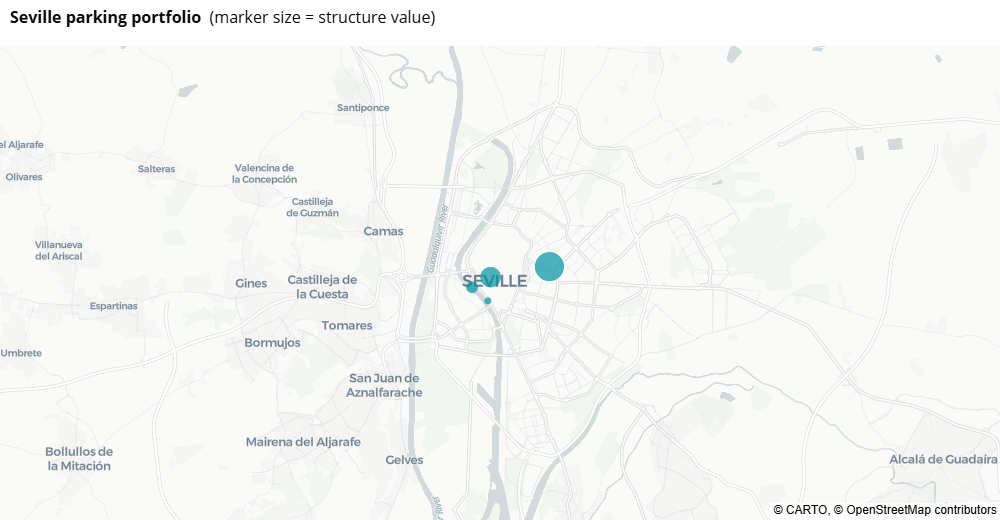

In [9]:
fig = gmp.show_portfolio(
    latitudes=[it["latitude"] for it in items], longitudes=[it["longitude"] for it in items],
    asset_ids=[it["id"] for it in items], names=[it["name"] for it in items],
    values=[it["value"] for it in items])
zoom_customized = 11
fig.update_layout(map=dict(zoom=zoom_customized), height=520, margin=dict(l=0, r=0, t=46, b=0),
                  title=dict(text="<b>Seville parking portfolio</b>  (marker size = structure value)",
                             font=dict(size=16, color=PALETTE["ink"]), x=0.01))
save_plot(fig, "p_portfolio_map")
fig.show()

## 4. Portfolio Risk Score Table

This section is the first portfolio triage layer. It asks a simple screening question before moving into detailed loss calculations: **which hazards appear most relevant for each parking asset, and under which scenario and year do they become most severe?**

The notebook sends the selected parking assets to the Alpha-Klima API and requests risk scores across the hazards, scenarios, and years defined in the `ANALYSIS_OPTIONS` of the _2.2 Inputs_ section. The API response includes risk as a 0-to-3 score:

- `0`: no material risk signal in the requested scope;
- `1`: low risk;
- `2`: medium risk;
- `3`: high risk.

For each asset and hazard, the table reports the **worst score reached across all requested scenarios and horizons**. This means the score is intentionally conservative for screening: if flood is low in 2035 but high in 2085, the flood column shows the high score so the hazard is not missed.

These scores are useful for prioritization, but they are **not the same as financial loss**. A high score means the facility has a strong hazard or impact signal in the requested scenario set; it does not by itself say how many euros are at risk. The later sections translate selected material hazards into financial views.

In [10]:
def score_item(it):
    "Asset under the parking occupancy routing used for the 0-3 score table."
    item = base_item(it)
    item.update({"occupancy_code": it.get("occupancy_code", 1113), "location": it.get("location", "Europe")})
    return item


resp = assess([score_item(it) for it in items], CONFIG["score_scope"],
              CONFIG["score_scenarios"], CONFIG["score_years"])
scores, drivers = score_matrix(resp, items)
scores.insert(1, "name", [it["name"] for it in items])
drivers.insert(1, "name", [it["name"] for it in items])

haz_cols = [h for h in CONFIG["score_scope"] if h in scores.columns]
scores["worst_score"] = scores[haz_cols].max(axis=1)
scores["worst_hazard"] = scores[haz_cols].idxmax(axis=1)
scores["worst_scenario_horizon"] = [drivers.loc[i, hz] for i, hz in scores["worst_hazard"].items()]
save_table(scores, "t_risk_scores")
_  = save_table(drivers, "t_risk_score_drivers")

print("Scenarios scanned:", ", ".join(CONFIG["score_scenarios"]))
print("Horizons scanned :", ", ".join(str(y) for y in CONFIG["score_years"]))

Scenarios scanned: historical, rcp4p5, rcp8p5, ssp126, ssp245, ssp585
Horizons scanned : 2005, 2035, 2050, 2085


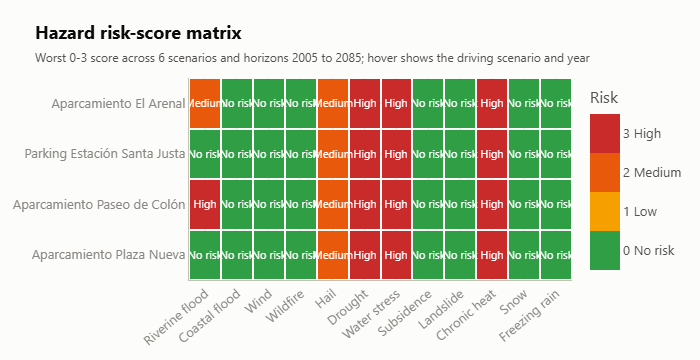

In [11]:
haz_cols = [h for h in CONFIG["score_scope"] if h in scores.columns]
order = scores.sort_values("worst_score", ascending=True)
z = order[haz_cols].to_numpy(dtype=float)
cd = drivers.set_index("id").loc[order["id"], haz_cols].to_numpy()   # driving scenario / year per cell
n = len(BAND_COLORS)
colorscale = []
for i, c in enumerate(BAND_COLORS):
    colorscale += [[i / n, c], [(i + 1) / n, c]]
fig = go.Figure(go.Heatmap(
    z=z, x=[HAZARD_LABEL[h] for h in haz_cols], y=order["name"], customdata=cd,
    text=[[SCORE_LABELS.get(int(v), "") if v == v else "" for v in row] for row in z],
    texttemplate="%{text}", textfont=dict(size=11, color="white"),
    colorscale=colorscale, zmin=-0.5, zmax=3.5,
    colorbar=dict(title="Risk", tickvals=[0, 1, 2, 3], ticktext=["0 No risk", "1 Low", "2 Medium", "3 High"]),
    hovertemplate="%{y}<br>%{x}: score %{z}<br>first reached at %{customdata}<extra></extra>", xgap=2, ygap=2))
style_plot(fig, "Hazard risk-score matrix",
           f"Worst 0-3 score across {len(CONFIG['score_scenarios'])} scenarios and horizons "
           f"{min(CONFIG['score_years'])} to {max(CONFIG['score_years'])}; "
           f"hover shows the driving scenario and year", height=360)
fig.update_xaxes(tickangle=-40)
save_plot(fig, "p_score_matrix")
fig.show()

Each score above is the **worst** band reached over those scenarios and horizons. The table hover shows *where* each one occurs, as `scenario / year`, so every cell traces back to a specific scenario and horizon. Where a hazard reaches the same worst band under several scenarios or horizons, the **earliest** one is reported: `historical / 2005` therefore means the hazard is already at that band today, not only under a future scenario.

**Reading the table.** The 0-to-3 scores are all shown in the same format, but they are not all calculated in the same way.

For some hazards, Alpha-Klima can apply a **damage or impact model** for the asset type. In those cases, the score reflects both the hazard intensity and how vulnerable the parking asset is expected to be. In this notebook, that applies to riverine and coastal flood, chronic heat, wind, wildfire, and landslide.

For other hazards, the score is a **hazard screening signal**. The API evaluates the hazard indicator itself against fixed thresholds, without applying a parking-specific damage curve. In this notebook, that applies to water stress, subsidence, drought, hail, snow, and freezing rain.

This distinction matters because a score tells us where to focus, but not always how to price the risk. The next sections price the two hazards that are most material for this parking portfolio: **flood** and **heat**. The traceability section at the end records the method used for every hazard.


## 5. Flood Loss View per Asset

The score table showed that flood is one of the material hazards for this parking portfolio. This section therefore moves from a **screening score** to a **financial loss view** for the headline flood case configured in the `ANALYSIS_OPTIONS` of the _2.2 Inputs_ section.

The notebook prices flood in one API request, but it sends two kinds of asset representation for each parking location:

- **Parking building**: the garage or deck together with the fixed equipment inside it. The value base comes from `value` in `parkings_seville.json`, which is `structure_value` plus `contents_value`, and the flood impact is based on the parking occupancy route used by the API.
- **Vehicles**: a proxy vehicle portfolio located at the same coordinates. The notebook creates one `TransportationAsset` per fleet type, such as sedan or SUV, so the vehicle component can use vehicle flood vulnerability curves rather than a building curve.

For each component, the API returns a flood damage ratio. The notebook converts that ratio into euros by multiplying it by the relevant value base:

- building loss = `value x combined damage ratio`;
- vehicle loss = `parking_spaces x occupancy x average vehicle value x fleet mix x vehicle damage ratio`.

This matters because vehicles can be a large part of the flood-exposed value in a car park. A concrete parking structure may be relatively resilient, while vehicles present during a flood can be much more vulnerable. Excluding vehicles would therefore understate the financial risk for many parking assets.

The same API response also includes a loss-exceedance distribution. That distribution is used later in the notebook to calculate tail-risk metrics such as Value-at-Risk and Expected Shortfall.

**How the damage curve is composed:** the platform resolves the parking occupancy to a single combined _Hazus COM10_ curve that already covers structure, components and inventory damage, so it returns one damage ratio per asset rather than a per-component breakdown. Selecting an individual damage component is a planned platform feature. The notebook applies that combined ratio to `value`, which is `structure_value` plus `contents_value`, so the value base covers the same things as the curve. Contents here means the fixed equipment that is not structure: machines, cabins, posts, signage fixed to the surfaces and similar. Vehicles are treated as a separate analysis, sent as their own assets so they reach vehicle flood curves instead of the building occupancy curve.


In [12]:
FLOOD_SCOPE = {"RiverineInundation": ["flood_depth"], "CoastalInundation": ["flood_depth"]}
HZ, SC, YR = CONFIG["flood_headline"]
OCC = CONFIG["fallback_occupancy_code"]


def parking_struct_item(it):
    "Structure asset for flood pricing, using JSON values first and flood defaults only if missing."
    item = base_item(it)
    item.update({"occupancy_code": it.get("occupancy_code", 1113), "location": it.get("location", "Europe"),
                 "number_of_storeys": it.get("number_of_storeys", -1),
                 "basement": it.get("basement", 0),
                 "first_floor_height": it.get("first_floor_height", 0.305)})
    return item

# proxy vehicles portfolio (per location) 
def vehicle_items(it):
    "One TransportationAsset per fleet family (type=Vehicle/*) for USACE vehicle curves."
    out = []
    for vt in CONFIG["fleet_mix"]:
        v = base_item(it)
        v["id"] = f'{it["id"]}-veh-{vt}'
        v["asset_name"] = f'{it["name"]} [{vt}]'
        v.update({"asset_class": "TransportationAsset", "type": f"Vehicle/{vt}", "occupancy_code": OCC})
        out.append(v)
    return out

#flood risk analysis for the proxy vehicle portfolio
flood_items = [parking_struct_item(it) for it in items] + [v for it in items for v in vehicle_items(it)]
flood = assess(flood_items, FLOOD_SCOPE, CONFIG["flood_scenarios"], CONFIG["flood_years"])
ratios = ratio_by_id(flood, HZ, SC, YR)

rows = []
for it in items:
    rid = str(it["id"]); r = ratios.get(rid, 0.0)
    expected_vehicle_loss = sum(it["vehicle_exposure"] * frac * ratios.get(f"{rid}-veh-{vt}", 0.0)
                       for vt, frac in CONFIG["fleet_mix"].items())
    rows.append({"id": rid, "name": it["name"], "building_value": it["value"],
                 "damage_ratio": r, "expected_building_loss": it["value"] * r, "expected_vehicle_loss": expected_vehicle_loss})
flood_df = pd.DataFrame(rows)
flood_df["expected_total_flood_loss"] = flood_df[["expected_building_loss", "expected_vehicle_loss"]].sum(axis=1)
save_table(flood_df, "t_flood_loss")
print("Total expected flood loss EUR", round(flood_df["expected_total_flood_loss"].sum() / 1e3, 1), "k/yr (", SC, YR, ")")
display(flood_df[["name", "damage_ratio", "expected_building_loss", "expected_vehicle_loss", "expected_total_flood_loss"]])

Total expected flood loss EUR 1716.2 k/yr ( rcp8p5 2085 )


,name,damage_ratio,expected_building_loss,expected_vehicle_loss,expected_total_flood_loss
0,Aparcamiento Plaza Nueva,0.00000,0.0,0.000,0.000
1,Aparcamiento Paseo de Colón,0.05812,717782.0,306001.800,1023783.800
2,Parking Estación Santa Justa,0.00000,0.0,0.000,0.000
3,Aparcamiento El Arenal,0.03002,330820.4,361552.896,692373.296


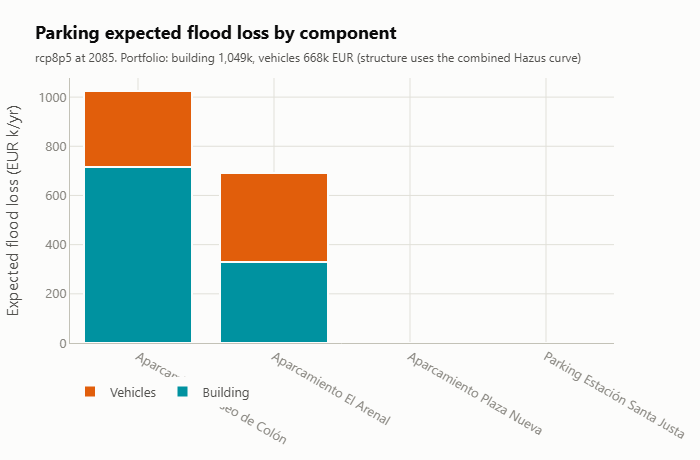

In [13]:
comp = flood_df.sort_values("expected_total_flood_loss", ascending=False)
fig = go.Figure()
for col, name in [("expected_building_loss", "Building"), ("expected_vehicle_loss", "Vehicles")]:
    fig.add_trace(go.Bar(x=comp["name"], y=comp[col] / 1e3, name=name, marker_color=COMPONENT_COLOR[name],
                         marker_line=dict(width=2, color=PALETTE["surface"]),
                         hovertemplate="%{x} " + name + ": %{y:,.1f}k EUR<extra></extra>"))
fig.update_layout(barmode="stack")
fig.update_yaxes(title="Expected flood loss (EUR k/yr)")
ct = comp[["expected_building_loss", "expected_vehicle_loss"]].sum()
style_plot(fig, "Parking expected flood loss by component",
           f"{SC} at {YR}. Portfolio: building {ct['expected_building_loss']/1e3:,.0f}k, "
           f"vehicles {ct['expected_vehicle_loss']/1e3:,.0f}k EUR (structure uses the combined Hazus curve)", height=460)
save_plot(fig, "p_flood_components")
fig.show()

### Flood Tail Risk: Value-at-Risk and Expected Shortfall

Expected annual loss is useful, but it only describes the average. For flood risk, the average can hide severe but less frequent outcomes. This section therefore looks at the **tail** of the flood loss distribution for the selected asset.

Two tail-risk metrics are shown:

- **Value-at-Risk (VaR)**: the loss level associated with a chosen confidence level. For example, VaR 99% is the 1-in-100 annual loss level: in the modelled distribution, losses exceed that value with about 1% annual probability.
- **Expected Shortfall (ES)**: the average loss in the same worst tail. For example, ES 99% is the average loss conditional on being in the worst 1% of outcomes. Because ES averages losses beyond the VaR threshold, it is always equal to or larger than VaR.

This asset-level tail view does not call Alpha-Klima's full production financial engine. Instead, it calculates these metrics client-side from the `impact_distribution` already returned by the asset-impact API. The flood request sends the parking building and each vehicle family as separate components, so the API returns one impact distribution for the building and one for each vehicle type.

For this parking example, the component losses are added together. This assumes the components are driven by the same flood event at the same location: if the parking asset floods, the structure and the vehicles present are affected together. This is why the notebook adds component VaR and ES values. Vehicle losses often dominate the tail because flood damage to a vehicle can be close to a total loss. Garage contents are not currently included.

The calculation is implemented in `auxiliary_functions/tail_metrics.py`. This is a temporary client-side helper intended to mirror the Alpha-Klima financial methodology until the equivalent platform API endpoint is available. Percentiles use the 0-to-100 convention: use `99`, not `0.99`, for VaR 99%.

`CONFIG["var_es_interpolate"]` controls how quantiles are read from the binned `impact distribution`. When interpolation is enabled, the notebook reads the quantile from a piecewise-linear cumulative distribution. This is smoother for single-asset examples where the API returns only a small number of bins. If interpolation is disabled, the result snaps to the discrete bin values instead.

The table below breaks the selected asset's tail risk into building and vehicle components. The charts then compare total flood VaR and Expected Shortfall across percentiles and climate scenarios.

The vehicle component reaches total loss once the flood depth passes the point where the vehicle curves saturate. Beyond that depth the vehicle loss cannot grow any further, so the vehicle VaR is flat across the higher confidence levels while the structure component keeps rising.


In [14]:
VE_ID = CONFIG["var_es_asset"]
PCTS = CONFIG["var_es_percentiles"]
INTERP = CONFIG["var_es_interpolate"]
ve = next(it for it in items if str(it["id"]) == VE_ID)


def component_var_es(scenario, year):
    "VaR/ES per component (structure, vehicles) for one scenario/year, as {percentile: (VaR, ES)}."
    be, bp = distribution(flood, VE_ID, HZ, scenario, year)
    building = tm.var_es(be, bp, PCTS, scale=ve["value"], interpolate=INTERP)

    # Every vehicle family sees the same flood depth, so family losses are comonotonic: VaR and ES add.
    veh = {p: (0.0, 0.0) for p in PCTS}
    for vt, frac in CONFIG["fleet_mix"].items():
        be, bp = distribution(flood, f"{VE_ID}-veh-{vt}", HZ, scenario, year)
        fam = tm.var_es(be, bp, PCTS, scale=ve["vehicle_exposure"] * frac, interpolate=INTERP)
        veh = {p: (veh[p][0] + fam[p][0], veh[p][1] + fam[p][1]) for p in PCTS}
    return {"building": building, "vehicles": veh}


# Per-component table for the headline scenario.
comp = component_var_es(SC, YR)
ve_rows = []
for p in PCTS:
    tot = tuple(sum(comp[k][p][j] for k in comp) for j in (0, 1))
    ve_rows.append({"confidence": f"{p / 100:.1%}", "return_period": f"1-in-{round(1 / (1 - p / 100))}",
                    "VaR_building_k": round(comp["building"][p][0] / 1e3),
                    "VaR_vehicles_k": round(comp["vehicles"][p][0] / 1e3),
                    "VaR_total_k": round(tot[0] / 1e3), "ES_total_k": round(tot[1] / 1e3)})
var_es_df = pd.DataFrame(ve_rows)
save_table(var_es_df, "t_var_es")
print(ve["name"], "| 1-in-100 flood VaR EUR", var_es_df.loc[var_es_df["return_period"] == "1-in-100", "VaR_total_k"].iat[0],
      "k | ES EUR", var_es_df.loc[var_es_df["return_period"] == "1-in-100", "ES_total_k"].iat[0], "k")
display(var_es_df)

Aparcamiento El Arenal | 1-in-100 flood VaR EUR 12853 k | ES EUR 13422 k


,confidence,return_period,VaR_building_k,VaR_vehicles_k,VaR_total_k,ES_total_k
0,95.0%,1-in-20,4710,6221,10931,12093
1,99.0%,1-in-100,6632,6221,12853,13422
2,99.5%,1-in-200,7167,6221,13388,13723


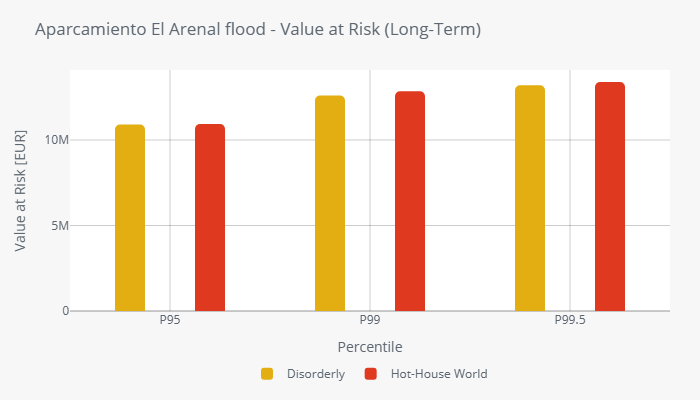

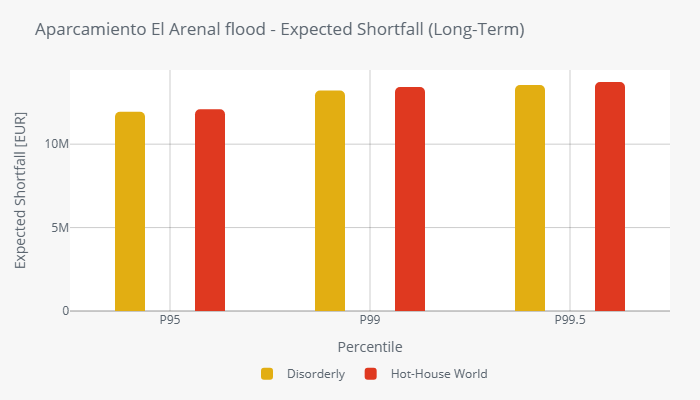

In [15]:
# Total (comonotonic) VaR and ES per scenario and percentile, plotted with the shared helpers.
totals = {s: component_var_es(s, YR) for s in CONFIG["flood_scenarios"]}
combined = {s: {p: tuple(sum(cv[k][p][j] for k in cv) for j in (0, 1)) for p in PCTS}
            for s, cv in totals.items()}

# One payload carries both metrics; each plotter selects its own rows by label.
resp = tm.metrics_response(combined, term="long")
fig = fmp.plot_var(resp, name=ve["name"] + " flood")
save_plot(fig, "p_var")
fig.show()
fig = fmp.plot_es(resp, name=ve["name"] + " flood")
save_plot(fig, "p_es")
fig.show()

## 6. Chronic Heat View per Asset

Chronic heat is a **chronic hazard**. Unlike acute risks, which result in single damaging episodes, chronic heat builds up gradually due to increasingly warmer conditions over time; therefore, in this section, it is interpreted as an **additional operating cost** rather than as a single harmful event.

The physical indicator used here is **cooling degree days**. Cooling degree days measure how much, and for how long, outdoor temperature is above a chosen cooling threshold. In this notebook the threshold is `heat_base_c`, set to 24 degrees C in the configuration of the _2.1 Inputs_ section. Higher cooling degree days indicate more demand for air conditioning or ventilation.

The notebook requests cooling-degree-day values from the Alpha-Klima hazard data API at each parking location for two cases:

- a historical baseline, configured as `heat_hist_scenario` and `heat_hist_year`;
- a future climate case, configured as `heat_scenario` and `heat_year`.

The result shown below is **not the total cooling bill**. It is the estimated additional cooling cost caused by warming: future cooling demand minus the historical baseline. This makes the output easier to interpret as climate-driven incremental cost rather than normal operating expenditure.

To convert additional cooling demand into euros, the notebook uses the helper in `auxiliary_functions/cooling_model.py`. The calculation scales cooling demand by an estimated floor area, derived from `parking_spaces x m2_per_parking_space`, applies simple cooling-system assumptions, and then prices the electricity demand using `electricity_tariff_eur_per_kwh`.

This is a transparent client-side interpretation layer built from API hazard data and configurable economic assumptions. The 0-to-3 chronic-heat score in the earlier screening table still comes from the platform score response, while the euro cost below is calculated in the notebook. Therefore the score and cost are related, but they are not the same metric and should not be expected to move one-for-one.


In [16]:
HEAT_SC, HEAT_YR = CONFIG["heat_scenario"], CONFIG["heat_year"]
lats = [it["latitude"] for it in items]; lons = [it["longitude"] for it in items]
cdd_now = heat_cdd_at_points(lats, lons, HEAT_SC, HEAT_YR, CONFIG["heat_base_c"])
cdd_hist = heat_cdd_at_points(lats, lons, CONFIG["heat_hist_scenario"], CONFIG["heat_hist_year"], CONFIG["heat_base_c"])

rows = []
for it, h, c in zip(items, cdd_hist, cdd_now):
    area = it["parking_spaces"] * CONFIG["m2_per_parking_space"]
    rows.append({"id": str(it["id"]), "name": it["name"], "floor_area_m2": area,
                 "cdd_hist": h, "cdd_2050": c,
                 "excess_cooling_cost_eur": cm.excess_cooling_cost_eur(
                     c, h, area, tariff_eur_per_kwh=CONFIG["electricity_tariff_eur_per_kwh"])})
heat_df = pd.DataFrame(rows)
heat_df["cdd_change"] = (heat_df["cdd_2050"] - heat_df["cdd_hist"]).clip(lower=0)
save_table(heat_df, "t_heat")
print("Total additional cooling cost vs baseline EUR",
      round(heat_df["excess_cooling_cost_eur"].sum() / 1e3, 1), "k/yr",
      "| mean CDD change:", round(np.nanmean(heat_df["cdd_change"])))
display(heat_df)

Total additional cooling cost vs baseline EUR 52.4 k/yr | mean CDD change: 386


,id,name,floor_area_m2,cdd_hist,cdd_2050,excess_cooling_cost_eur,cdd_change
0,P1,Aparcamiento Plaza Nueva,18000,368.8,755.3,12940.020,386.5
1,P2,Aparcamiento Paseo de Colón,13500,368.8,755.3,9705.015,386.5
2,P3,Parking Estación Santa Justa,27000,368.8,755.3,19410.030,386.5
3,P9,Aparcamiento El Arenal,14400,368.8,755.3,10352.016,386.5


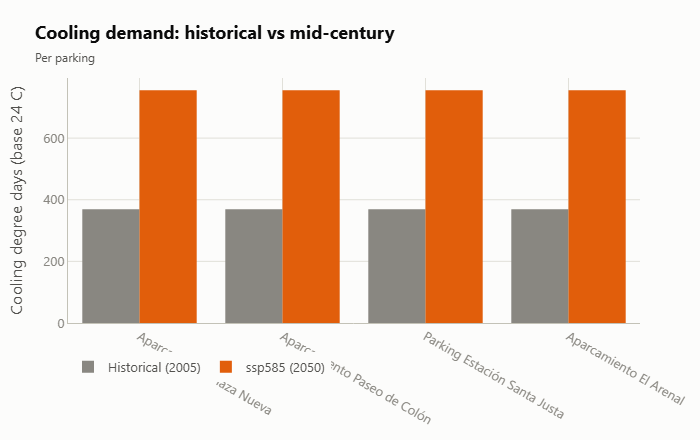

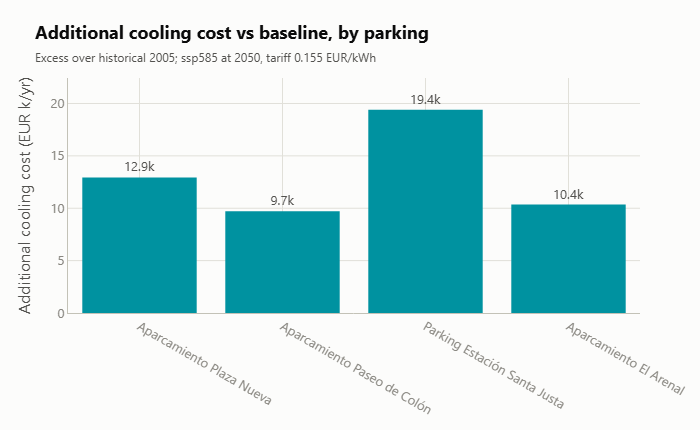

In [17]:
fig = go.Figure()
fig.add_trace(go.Bar(x=heat_df["name"], y=heat_df["cdd_hist"], name="Historical (2005)",
                     marker_color=PALETTE["muted"], marker_line_width=0,
                     hovertemplate="%{x} historical: %{y:,.0f} CDD<extra></extra>"))
fig.add_trace(go.Bar(x=heat_df["name"], y=heat_df["cdd_2050"], name=f"{HEAT_SC} ({HEAT_YR})",
                     marker_color=PALETTE["orange"], marker_line_width=0,
                     hovertemplate="%{x} " + str(HEAT_YR) + ": %{y:,.0f} CDD<extra></extra>"))
fig.update_layout(barmode="group")
fig.update_yaxes(title="Cooling degree days (base 24 C)")
style_plot(fig, "Cooling demand: historical vs mid-century", "Per parking", height=440)
save_plot(fig, "p_cdd_change")
fig.show()

fig2 = go.Figure(go.Bar(x=heat_df["name"], y=heat_df["excess_cooling_cost_eur"] / 1e3, marker_color=PALETTE["teal"],
                        marker_line_width=0, text=[f"{v/1e3:,.1f}k" for v in heat_df["excess_cooling_cost_eur"]],
                        textposition="outside", textfont=dict(color=PALETTE["ink2"]),
                        hovertemplate="%{x}: %{y:,.1f}k EUR/yr<extra></extra>"))
fig2.update_yaxes(title="Additional cooling cost (EUR k/yr)")
style_plot(fig2, "Additional cooling cost vs baseline, by parking",
           f"Excess over historical 2005; {HEAT_SC} at {HEAT_YR}, tariff "
           f"{CONFIG['electricity_tariff_eur_per_kwh']} EUR/kWh", height=430)
save_plot(fig2, "p_cooling_cost")
fig2.show()

## 7. Clustering

The asset-level sections above show how individual parking locations respond to flood and chronic heat. Clustering is the next portfolio-analysis step for acute hazards: it identifies groups of assets that can be affected by the same hazard event and therefore should not be treated as fully independent in portfolio risk aggregation.

The API clustering workflow is hazard-agnostic. It runs after the portfolio risk pipeline and returns cluster definitions plus asset-to-cluster links for the hazards where clustering is relevant and available.

Each acute hazard uses its own spatial method, so both the cluster layout and the form of the cluster identifiers depend on the hazard being clustered. The clustering methods are described in the platform documentation.

> Warning: the portfolio risk and clustering runs may take a few minutes.


In [18]:
def cluster_portfolio_item(it):
    "Physical-asset portfolio record for clustering the parking structures."
    return {
        "id": str(it["id"]),
        "name": it["name"],
        "latitude": it["latitude"],
        "longitude": it["longitude"],
        "country": it.get("country", "ES"),
        "location": it.get("location", "Europe"),
        "occupancy_code": it.get("occupancy_code", 1113),
        "number_of_storeys": it.get("number_of_storeys", -1),
        "basement": it.get("basement", 0),
        "first_floor_height": it.get("first_floor_height", 0.305),
        "value": it["value"],
    }


parking_cluster_portfolio = {
    "portfolio": {"assets": [cluster_portfolio_item(it) for it in items]},
    "portfolio_name": "seville_parkings_clustering_demo",
}

pipeline = PhysicalAssetPipeline(
    api_base=API_BASE,
    api_key=API_KEY,
    portfolio=parking_cluster_portfolio,
)
portfolio_code = pipeline.portfolio_code

_ = pipeline.run_risk_analysis(
    requested_results=[f"api/physical-asset-portfolios/{portfolio_code}/assets/risks"]
)
clustering_results = pipeline.run_clustering(requested_results=[
    f"api/physical-asset-portfolios/{portfolio_code}/clusters",
    f"api/physical-asset-portfolios/{portfolio_code}/clusters/assets",
])
clusters = clustering_results[f"api/physical-asset-portfolios/{portfolio_code}/clusters"]
asset2cluster = clustering_results[f"api/physical-asset-portfolios/{portfolio_code}/clusters/assets"]
print("Registered portfolio code:", portfolio_code)
print("Cluster records:", len(clusters), "| asset-cluster links:", len(asset2cluster))


Registered portfolio code: 2013
Cluster records: 3 | asset-cluster links: 24


These helpers reshape the clustering output into a more interpretable form:

- `available_clustering_hazards` lists the hazards for which the clustering pipeline returned clusters.
- `get_clusters_by_hazard` joins each cluster definition with the parking assets assigned to it.
- `show_clusters_for_hazard` renders the same cluster table and map for whichever hazard is selected.

In [19]:
def available_clustering_hazards(clusters: list[dict]) -> pd.DataFrame:
    "Returns a table with all available hazard combinations for clustering."
    hazards = {data["hazard"] for data in clusters}
    return pd.DataFrame([{"hazard": h} for h in hazards]).sort_values("hazard").reset_index(drop=True)


def get_clusters_by_hazard(clusters: list[dict], asset2cluster: list[dict], *, hazard: str) -> pd.DataFrame:
    rows = []
    for data in clusters:
        if data["hazard"] != hazard:
            continue

        cluster_name = data["cluster_name"]
        assets = sorted({
            a2c["client_asset_id"]
            for a2c in asset2cluster
            if a2c["cluster_name"] == cluster_name
        })
        rows.append({
            "cluster_id": data["cluster_id"],
            "assets": assets,
            "cluster_name": cluster_name,
            "value": data["value"],
            "geometry": data["geometry"],
        })

    return pd.DataFrame(rows)


def show_clusters_for_hazard(hazard: str) -> pd.DataFrame:
    clusters_df = get_clusters_by_hazard(clusters, asset2cluster, hazard=hazard)
    if clusters_df.empty:
        print("No clusters returned for", hazard)
        return clusters_df

    display(clusters_df)
    fig = gmp.plot_clusters(
        geometries=clusters_df["geometry"],
        cluster_names=clusters_df["cluster_name"],
        values=clusters_df["value"],
        asset_lat=[it["latitude"] for it in items],
        asset_lon=[it["longitude"] for it in items],
        asset_name=[it["name"] for it in items],
        hazard=hazard,
        height=520,
    )
    # plot_clusters already fits the view to the cluster footprints, which for the
    # wider hazards reach well beyond the assets inside them.
    fig.update_layout(
        margin=dict(l=0, r=0, t=46, b=0),
        title=dict(text=f"{HAZARD_LABEL.get(hazard, hazard)} clusters: Seville parkings"),
    )
    save_plot(fig, f"p_clusters_{hazard}")
    fig.show()
    return clusters_df


available_clustering_hazards(clusters)


,hazard
0,Combined
1,RiverineInundation
2,Wind


The list below shows the hazards returned by the clustering pipeline.

In [20]:
available_clustering_hazards_list = available_clustering_hazards(clusters)["hazard"].tolist()
if not available_clustering_hazards_list:
    raise ValueError("The clustering pipeline did not return any hazard clusters for this portfolio.")


For each returned hazard, the cluster table links the cluster identifier to the parking assets assigned to that footprint. The map is a practical quality check: assets assigned to the same cluster should make sense spatially for the selected hazard.


,cluster_id,assets,cluster_name,value,geometry
0,1,"[P1, P2, P3, P9]",Cluster 1,55570000.0,MULTIPOLYGON(((-6.040960783884467 37.588066471...


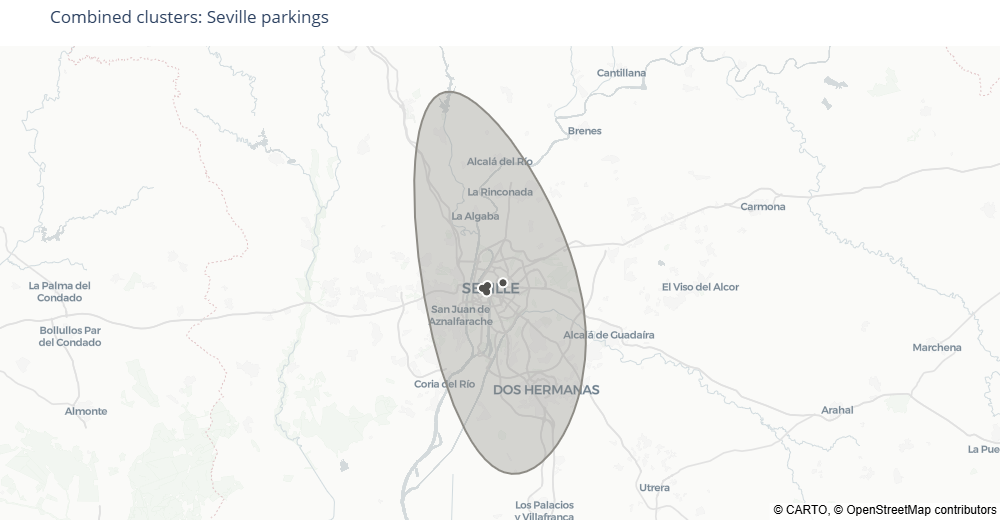

,cluster_id,assets,cluster_name,value,geometry
0,2090701490,"[P2, P9]",RiverineInundation cluster 2090701490,23370000.0,MULTIPOLYGON(((-5.933333333333316 37.262500000...


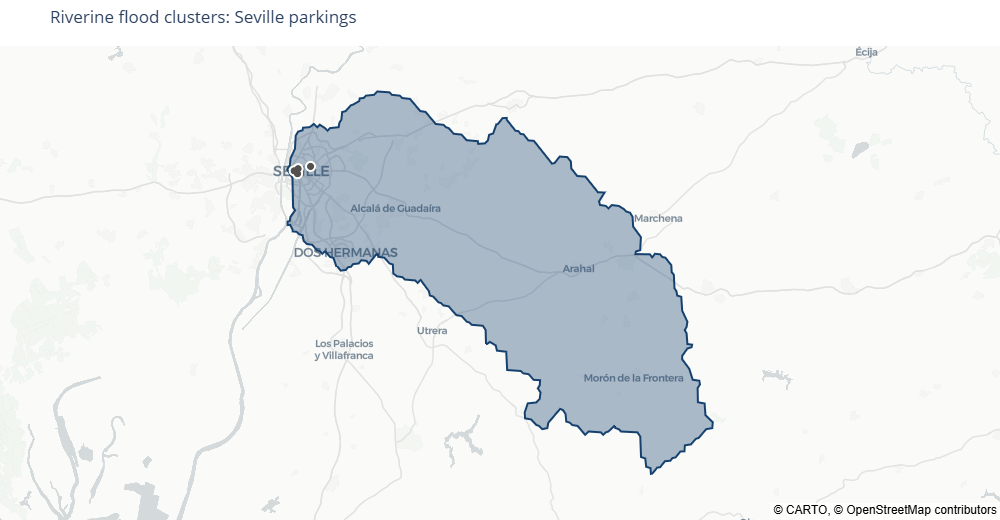

,cluster_id,assets,cluster_name,value,geometry
0,1,"[P1, P2, P3, P9]",Wind cluster 1,55570000.0,MULTIPOLYGON(((-6.040960783884467 37.588066471...


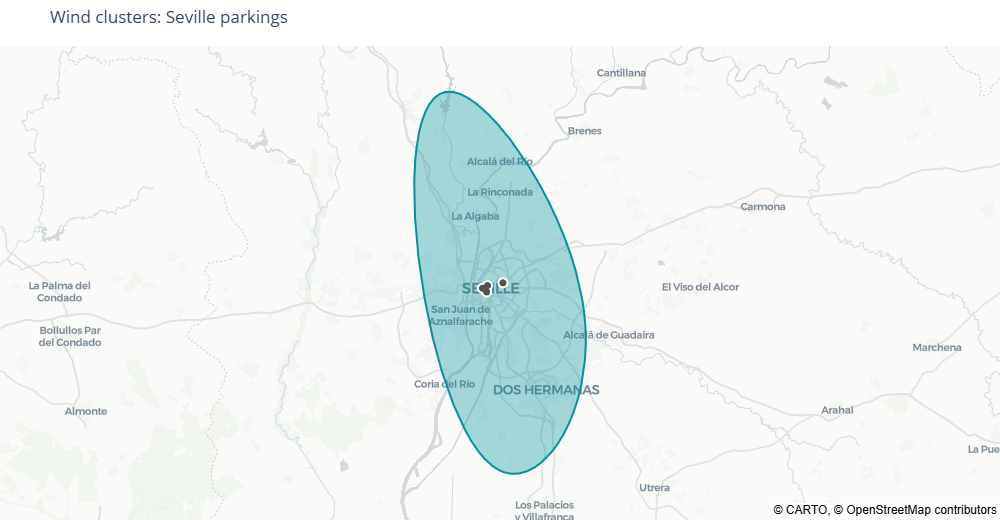

In [21]:
clusters_by_hazard = {hazard: show_clusters_for_hazard(hazard) for hazard in available_clustering_hazards_list}

## 8. Portfolio View

The previous sections looked at risk one asset or one hazard component at a time. The portfolio view asks a different question: after the assets have been registered, analysed, and clustered where relevant, what does the aggregated risk profile look like for the selected parking portfolio?

For acute hazards, the portfolio-level endpoints use the results of the clustering pipeline in the aggregation. This means assets assigned to the same hazard cluster can contribute to the same event-loss distribution rather than being treated as unrelated observations.


Use the portfolio-level endpoints when you want the total risk profile rather than the contribution of one asset or one spatial cluster. Following the real-estate workflow, the example below requests the `Combined` portfolio view. To inspect one hazard only, set `portfolio_hazard` to a value such as `cluster_hazard`.


In [22]:
portfolio_hazard = "Combined"

portfolio_hazard_exceedance = requests.get(
    url=f"{API_BASE}/api/physical-asset-portfolios/{portfolio_code}/exceedance-curves?hazard={portfolio_hazard}",
    headers=HEADERS,
)
portfolio_metrics = requests.get(
    url=f"{API_BASE}/api/physical-asset-portfolios/{portfolio_code}/metrics?hazard={portfolio_hazard}",
    headers=HEADERS,
)
for response in [portfolio_hazard_exceedance, portfolio_metrics]:
    response.raise_for_status()

print("Portfolio hazard:", portfolio_hazard)


Portfolio hazard: Combined


This curve represents total portfolio losses after aggregation across all relevant assets, hazards, and clusters included in the selected portfolio view.


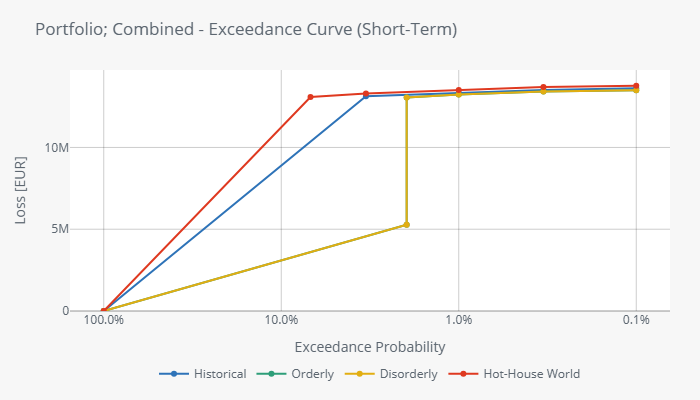

In [23]:
fig = fmp.plot_exceedance_curves(
    portfolio_hazard_exceedance,
    name=f"Portfolio; {HAZARD_LABEL.get(portfolio_hazard, portfolio_hazard)}",
    selected_term="short",
)
save_plot(fig, "p_portfolio_exceedance")
fig.show()


Portfolio VaR summarizes severe-but-plausible downside loss at whole-portfolio level. Expected Shortfall complements it by averaging the severity of outcomes beyond the same confidence threshold.


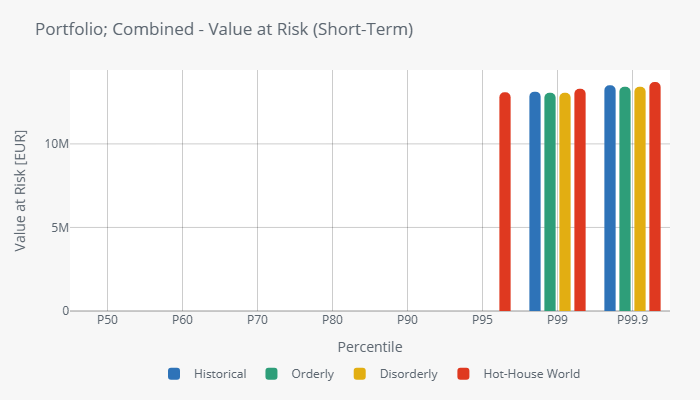

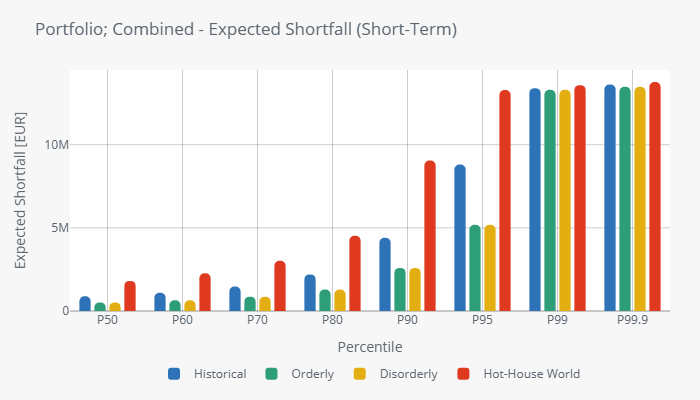

In [24]:
fig = fmp.plot_var(
    portfolio_metrics,
    name=f"Portfolio; {HAZARD_LABEL.get(portfolio_hazard, portfolio_hazard)}",
    selected_term="short",
)
save_plot(fig, "p_portfolio_var")
fig.show()

fig = fmp.plot_es(
    portfolio_metrics,
    name=f"Portfolio; {HAZARD_LABEL.get(portfolio_hazard, portfolio_hazard)}",
    selected_term="short",
)
save_plot(fig, "p_portfolio_es")
fig.show()


The platform portfolio metrics above are the main aggregated risk view. The small summary table below keeps one useful management-facing bridge from the earlier asset-level sections: it shows the expected flood components and the chronic-heat operating-cost estimate side by side, without replacing the clustering-adjusted portfolio tail metrics.

The chart below the table shows the same three components as shares of the annual total: flood damage to the parking building, flood damage to the vehicles parked in it, and the additional cooling cost from chronic heat. Expected losses add, so these shares do sum to the total, which is what makes a share view meaningful here.


Indicative annual cost components EUR 1768.6 k/yr


,component,eur_per_year
0,Flood: building,1048602.400
1,Flood: vehicles,667554.696
2,Heat: additional cooling,52407.081


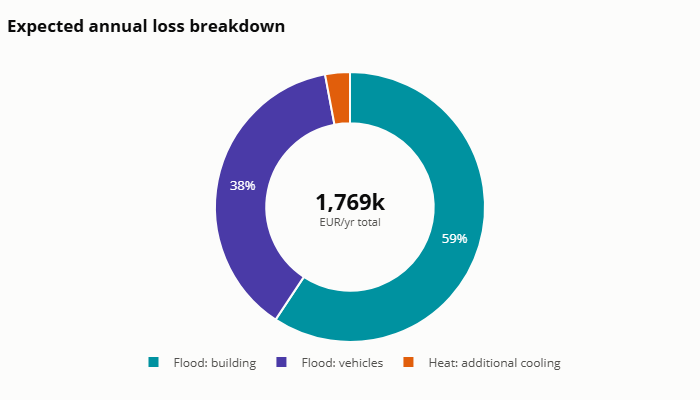

In [25]:
portfolio_summary = pd.DataFrame({
    "component": ["Flood: building", "Flood: vehicles", "Heat: additional cooling"],
    "eur_per_year": [
        flood_df["expected_building_loss"].sum(),
        flood_df["expected_vehicle_loss"].sum(),
        np.nansum(heat_df["excess_cooling_cost_eur"]),
    ],
})
save_table(portfolio_summary, "t_portfolio_summary")
print("Indicative annual cost components EUR", round(portfolio_summary["eur_per_year"].sum() / 1e3, 1), "k/yr")
display(portfolio_summary)

fig = bdc.loss_mix_donut(
    dict(zip(portfolio_summary["component"], portfolio_summary["eur_per_year"], strict=True)),
)
save_plot(fig, "p_loss_mix")
fig.show()


## 9. Provenance by Asset

The previous sections produced portfolio-level charts and headline financial metrics. This section brings the results back down to the individual asset level, so the user can see exactly what sits behind those summaries.

The provenance table is designed as an audit and review aid. Each row represents one parking asset and combines the main inputs and outputs used in the priced hazard views:

- the asset identity and location;
- the value bases used for the building and vehicle calculations;
- the flood damage ratio returned by the API for the configured headline flood case;
- the expected structure, vehicle, and total flood loss;
- the estimated additional cooling cost from the chronic-heat calculation.

This table is useful when a reviewer asks why a particular asset is driving the portfolio result. The reviewer can trace the result back to the asset's coordinates, exposure assumptions, scenario, year, and model output.


In [26]:
prov = flood_df[["id", "name", "building_value", "damage_ratio", "expected_building_loss",
                 "expected_vehicle_loss", "expected_total_flood_loss"]].copy()
prov = prov.merge(heat_df[["id", "cdd_2050", "excess_cooling_cost_eur"]], on="id", how="left")
prov = prov.merge(scores[["id", "worst_score"]], on="id", how="left")
prov["flood_routing"] = "occ 1113 (COM10 combined curve) + Vehicle/* (occ -1)"
save_table(prov, "t_provenance")
display(prov.sort_values("expected_total_flood_loss", ascending=False).reset_index(drop=True))

,id,name,building_value,damage_ratio,expected_building_loss,expected_vehicle_loss,expected_total_flood_loss,cdd_2050,excess_cooling_cost_eur,worst_score,flood_routing
0,P2,Aparcamiento Paseo de Colón,12350000,0.05812,717782.0,306001.800,1023783.800,755.3,9705.015,3,occ 1113 (COM10 combined curve) + Vehicle/* (o...
1,P9,Aparcamiento El Arenal,11020000,0.03002,330820.4,361552.896,692373.296,755.3,10352.016,3,occ 1113 (COM10 combined curve) + Vehicle/* (o...
2,P1,Aparcamiento Plaza Nueva,14900000,0.00000,0.0,0.000,0.000,755.3,12940.020,3,occ 1113 (COM10 combined curve) + Vehicle/* (o...
3,P3,Parking Estación Santa Justa,17300000,0.00000,0.0,0.000,0.000,755.3,19410.030,3,occ 1113 (COM10 combined curve) + Vehicle/* (o...


## 10. Traceability and Methodology

This section explains which method sits behind each hazard in this notebook. This is important because the hazard score table uses a consistent 0-to-3 format, but the underlying calculation is not identical for every hazard.

The traceability table distinguishes between two broad types of score:

- **IMPACT scores**, where the API applies a vulnerability or damage model to translate hazard intensity into an asset impact signal;
- **HAZARD scores**, where the API reads the hazard indicator directly against fixed thresholds because no asset-specific damage curve is used in this workflow.

The table also identifies which parts are returned by the Alpha-Klima API and which parts are assembled in the notebook. In this run, flood impact results come from the platform response, while the chronic-heat euro cost is a client-side calculation based on API cooling-degree-day data and the assumptions configured earlier. The parking occupancy resolves to a combined damage curve, and the value base it is applied to is `value`, the sum of `structure_value` and `contents_value`, so the fixed contents sit inside both the curve and the base.

The table below is assembled in the notebook from what is published on the platform documentation site, so it is a curated view of documented material rather than anything derived here. Everything in it can be read there in full, which is also the place to look for the hazard models, the vulnerability curves and the scoring methodology behind each row.

Use this section when validating the workflow internally, explaining results to non-technical stakeholders, or deciding which assumptions a client team may want to replace with its own data. Full methodology documentation is available on the Alpha-Klima documentation site: [https://platform.alpha-klima.com/docs/index.html](https://platform.alpha-klima.com/docs/index.html).


In [27]:
TRACE = [
 ("RiverineInundation", "flood_depth", "occ 1113 -> Hazus COM10", "WRI flood depth + Hazus COM10 garage combined curve", "IMPACT", "platform", "Specific garage curve for parking occupancy", "WRI Aqueduct; FEMA Hazus"),
 ("CoastalInundation", "flood_depth", "occ 1113 -> Hazus COM10", "WRI coastal flood depth + Hazus COM10 combined curve", "IMPACT", "platform", "Same garage curve as riverine", "WRI Aqueduct; FEMA Hazus"),
 ("Flood vehicles", "flood_depth", "TransportationAsset Vehicle/* (occ -1)", "Martinez-Gomariz urban-flood vehicle curves", "IMPACT", "platform", "One asset per vehicle family; exposure = spaces x occupancy x avg value x fleet mix", "Martinez-Gomariz et al. 2019"),
 ("Flood damage components", "flood_depth", "occ 1113 -> Hazus COM10 (combined)", "Structure, components and inventory combined in one curve", "IMPACT", "platform", "One combined damage ratio is returned; selecting an individual damage component is on the way", "FEMA Hazus"),
 ("Flood tail (VaR/ES)", "flood_depth", "per-component impact_distribution", "Discrete quantile + tail mean over the impact PMF; interpolated within bins when CONFIG['var_es_interpolate']", "IMPACT", "client-side", "Mirrors the Alpha-Klima financial module; temporary until the platform exposes tail metrics through the API", "Alpha-Klima financial module"),
 ("ChronicHeat", "cooling_degree_days/index", "occ 1113 -> RealEstate", "Score: platform cooling model. Cost: excess CDD (scenario - historical 2005) x UA(floor area x per-m2 coeff) / COP", "IMPACT", "platform score / client-side cost", "Cost is the excess over baseline scaled by building size; provisional model, with an enhanced methodology being onboarded into the platform", "ECB SPS No.48; cooling model"),
 ("Wind", "wind_speed/3s", "occ 1113", "WISC 3s gust + generic building wind curve", "IMPACT", "platform", "COM10 has no wind curve, so a generic building curve applies under occ 1113", "WISC; JRC/Huizinga"),
 ("Fire", "fire_probability", "occ 1113", "Generic wildfire damage curve", "IMPACT", "platform", "Generic curve applies under occ 1113; no parking-specific fire curve", "Alpha-Klima wildfire"),
 ("Landslide", "landslide_susceptability", "occ 1113", "Landslide susceptibility damage curve", "IMPACT", "platform", "Susceptibility-based damage", "JRC"),
 ("WaterRisk", "water_stress", "occ 1113", "None (score from intensity)", "HAZARD", "platform", "Score-only: no damage curve, read from water-stress ratio", "WRI Aqueduct 4.0"),
 ("Subsidence", "subsidence_susceptability", "occ 1113", "None (score from intensity)", "HAZARD", "platform", "Score-only: susceptibility index thresholds", "JRC"),
 ("Drought", "cdd", "occ 1113", "None (score from intensity)", "HAZARD", "platform", "Score-only: consecutive dry days thresholds", "Copernicus"),
 ("Hail", "hail_probability", "occ 1113", "None (score from intensity)", "HAZARD", "platform", "Score-only: annual large-hail probability", "TU Delft RAIN"),
 ("Snow", "blizzard_probability", "occ 1113", "None (score from intensity)", "HAZARD", "platform", "Score-only: annual blizzard probability", "TU Delft RAIN"),
 ("FreezingRain", "freezing_rain_probability", "occ 1113", "None (score from intensity)", "HAZARD", "platform", "Score-only: freezing-rain probability", "TU Delft RAIN"),
]
trace_df = pd.DataFrame(TRACE, columns=["hazard", "indicator_id", "routing", "model / curve resolved",
                                        "score source", "computed by", "why this model", "reference"])
save_table(trace_df, "t_traceability")
display(trace_df)

,hazard,indicator_id,routing,model / curve resolved,score source,computed by,why this model,reference
0,RiverineInundation,flood_depth,occ 1113 -> Hazus COM10,WRI flood depth + Hazus COM10 garage combined ...,IMPACT,platform,Specific garage curve for parking occupancy,WRI Aqueduct; FEMA Hazus
1,CoastalInundation,flood_depth,occ 1113 -> Hazus COM10,WRI coastal flood depth + Hazus COM10 combined...,IMPACT,platform,Same garage curve as riverine,WRI Aqueduct; FEMA Hazus
2,Flood vehicles,flood_depth,TransportationAsset Vehicle/* (occ -1),Martinez-Gomariz urban-flood vehicle curves,IMPACT,platform,One asset per vehicle family; exposure = space...,Martinez-Gomariz et al. 2019
3,Flood damage components,flood_depth,occ 1113 -> Hazus COM10 (combined),"Structure, components and inventory combined i...",IMPACT,platform,One combined damage ratio is returned; selecti...,FEMA Hazus
4,Flood tail (VaR/ES),flood_depth,per-component impact_distribution,Discrete quantile + tail mean over the impact ...,IMPACT,client-side,Mirrors the Alpha-Klima financial module; temp...,Alpha-Klima financial module
5,ChronicHeat,cooling_degree_days/index,occ 1113 -> RealEstate,Score: platform cooling model. Cost: excess CD...,IMPACT,platform score / client-side cost,Cost is the excess over baseline scaled by bui...,ECB SPS No.48; cooling model
6,Wind,wind_speed/3s,occ 1113,WISC 3s gust + generic building wind curve,IMPACT,platform,"COM10 has no wind curve, so a generic building...",WISC; JRC/Huizinga
7,Fire,fire_probability,occ 1113,Generic wildfire damage curve,IMPACT,platform,Generic curve applies under occ 1113; no parki...,Alpha-Klima wildfire
8,Landslide,landslide_susceptability,occ 1113,Landslide susceptibility damage curve,IMPACT,platform,Susceptibility-based damage,JRC
9,WaterRisk,water_stress,occ 1113,None (score from intensity),HAZARD,platform,"Score-only: no damage curve, read from water-s...",WRI Aqueduct 4.0


### Sources and assumptions
- Flood for the parking building uses the Hazus COM10 (garage) curve reached via OED occupancy 1113, which the platform serves as a single combined curve covering structure, components and inventory damage. Vehicles use the Martinez-Gomariz 2019 urban-flood curves, one asset per vehicle family; vehicle exposure is `parking_spaces x occupancy x avg_vehicle_value` (about 18,000 EUR) split over an illustrative fleet mix. Both components, including their loss-exceedance curves, are computed by the platform: the notebook needs no local vulnerability data.
- The combined curve returns one damage ratio per asset, applied to `value`, which is `structure_value` plus `contents_value`. Contents here means the fixed equipment that is not structure: machines, cabins, posts, signage fixed to the surfaces and similar. Selecting an individual damage component is a planned platform feature.
- Value-at-Risk and Expected Shortfall are computed client-side by `auxiliary_functions/tail_metrics.py` from the per-asset `impact_distribution` the API already returns, and rendered with the shared `financial_metrics_plots` helpers. The math mirrors Alpha-Klima's financial module, so the figures will not move when the platform exposes these metrics through the API. That module is temporary and should be deleted once those endpoints land.
- Chronic heat is reported as the additional cooling-energy cost vs the historical 2005 baseline, scaled by building floor area (about 30 m2 per parking space) and priced at a Spain electricity tariff of about 0.155 EUR/kWh. Tariff source: Eurostat `nrg_pc_205` (Spain, non-household band, incl. taxes and levies), recorded in `CONFIG["tariff_source"]`. Costs are in **constant (real) terms**: the current tariff is applied to future cooling demand with no energy-price inflation, so figures across horizons are directly comparable. This client-side calculation (`auxiliary_functions/cooling_model.py`) is a provisional model, and an enhanced methodology for it is being onboarded into the platform. The 0 to 3 heat score comes from the platform cooling model.
- The risk-score table is built from a single request under the parking occupancy routing (OED 1113), which resolves all hazards; score-only hazards carry no damage curve.
- Clustering is run through the physical-asset portfolio pipeline. The section displays whichever clustered hazards the API returns, with the configured flood hazards shown first when available.
- Scenario labels are transition narratives rather than pathway identifiers. When a requested narrative has no data for a given hazard, the platform resolves it to the closest available pathway, so two narratives can be served from the same underlying series and their curves overlap.
- Full model documentation (hazard models, vulnerability curves and the scoring methodology) is on the Alpha-Klima docs site: https://platform.alpha-klima.com/docs/index.html
- Asset values and parking attributes are illustrative. Results are for screening, not regulatory submission.

